In [80]:
import pandas as pd
import matplotlib.pyplot as plt
import mpltern
import numpy as np
from sklearn_extra.cluster import KMedoids
import matplotlib as mpl
import matplotlib.animation as animation

In [81]:
df = pd.read_csv('combined_solidus_karma_results.csv')
df

/var/folders/t8/1dshmvf55gn478cb8nbc9x880000gn/T/ipykernel_62839/3176721011.py:1: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('combined_solidus_karma_results.csv')


,Source,G,C,R,Vab,Prior,Truth,Explanation
0,Grid,100000.000000,0.15,0.012,0.408627,0,NaN,NaN
1,Grid,302040.816327,0.15,0.012,0.408627,0,NaN,NaN
2,Grid,504081.632653,0.15,0.012,0.408627,0,NaN,NaN
3,Grid,706122.448980,0.15,0.012,0.408627,0,NaN,NaN
4,Grid,908163.265306,0.15,0.012,0.408627,0,NaN,NaN
...,...,...,...,...,...,...,...,...
125048,Karma,100000.000000,0.19,0.030,0.630127,0,0.0,Cellular (not run)
125049,Karma,100000.000000,0.19,0.060,0.630127,0,0.0,Cellular (not run)
125050,Karma,100000.000000,0.19,0.120,0.630127,0,0.0,Cellular
125051,Karma,100000.000000,0.19,0.300,0.630127,0,0.0,Cellular (ish)


In [4]:
df[df['Source'] == 'Karma']

,Source,G,C,R,Vab,Prior,Truth,Explanation
125000,Karma,10000000.0,0.15,0.012,0.408627,0,0.0,Cellular
125001,Karma,10000000.0,0.15,0.030,0.408627,0,0.0,Cellular
125002,Karma,10000000.0,0.15,0.060,0.408627,0,0.0,Cellular
125003,Karma,10000000.0,0.15,0.120,0.408627,0,0.0,Cellular
125004,Karma,10000000.0,0.15,0.300,0.408627,0,1.0,Planar
125005,Karma,10000000.0,0.15,0.600,0.408627,1,1.0,Planar
125006,Karma,1000000.0,0.15,0.012,0.408627,0,0.0,Cellular (not run)
125007,Karma,1000000.0,0.15,0.030,0.408627,0,0.0,Cellular (not run)
125008,Karma,1000000.0,0.15,0.060,0.408627,0,0.0,Cellular
125009,Karma,1000000.0,0.15,0.120,0.408627,0,0.0,Cellular


In [35]:
df_grid = pd.read_csv('grid_df_after_initial_iteration.csv')
df_grid

,Source,G,C,R,Vab,Prior,Truth,Explanation,Prior_Scaled,Truth_Scaled,Predicted_Probability,Std_Dev
0,Grid,0.000000,0.0,0.0,0.408627,0,NaN,NaN,-0.405465,NaN,0.006693,0.000010
1,Grid,0.020408,0.0,0.0,0.408627,0,NaN,NaN,-0.405465,NaN,0.007469,0.537001
2,Grid,0.040816,0.0,0.0,0.408627,0,NaN,NaN,-0.405465,NaN,0.007864,0.633484
3,Grid,0.061224,0.0,0.0,0.408627,0,NaN,NaN,-0.405465,NaN,0.007710,0.599294
4,Grid,0.081633,0.0,0.0,0.408627,0,NaN,NaN,-0.405465,NaN,0.007076,0.396680
...,...,...,...,...,...,...,...,...,...,...,...,...
124995,Grid,0.918367,1.0,1.0,0.630127,0,NaN,NaN,-0.405465,NaN,0.882703,0.896978
124996,Grid,0.938776,1.0,1.0,0.630127,0,NaN,NaN,-0.405465,NaN,0.927845,0.840284
124997,Grid,0.959184,1.0,1.0,0.630127,0,NaN,NaN,-0.405465,NaN,0.961221,0.746953
124998,Grid,0.979592,1.0,1.0,0.630127,0,NaN,NaN,-0.405465,NaN,0.982268,0.578902


In [36]:
df_grid['Std_Dev'].max()

0.9999619034893984

In [7]:
df_train = pd.read_csv('train_df_after_initial_iteration.csv')
df_train

,Source,G,C,R,Vab,Prior,Truth,Explanation,Prior_Scaled,Truth_Scaled
0,Karma,1.000000,0.0,0.000000,0.408627,0,0.0,Cellular,-0.405465,-5.0
1,Karma,1.000000,0.0,0.030612,0.408627,0,0.0,Cellular,-0.405465,-5.0
2,Karma,1.000000,0.0,0.081633,0.408627,0,0.0,Cellular,-0.405465,-5.0
3,Karma,1.000000,0.0,0.183673,0.408627,0,0.0,Cellular,-0.405465,-5.0
4,Karma,1.000000,0.0,0.489796,0.408627,0,1.0,Planar,-0.405465,5.0
5,Karma,1.000000,0.0,1.000000,0.408627,1,1.0,Planar,0.405465,5.0
6,Karma,0.090909,0.0,0.000000,0.408627,0,0.0,Cellular (not run),-0.405465,-5.0
7,Karma,0.090909,0.0,0.030612,0.408627,0,0.0,Cellular (not run),-0.405465,-5.0
8,Karma,0.090909,0.0,0.081633,0.408627,0,0.0,Cellular,-0.405465,-5.0
9,Karma,0.090909,0.0,0.183673,0.408627,0,0.0,Cellular,-0.405465,-5.0


/opt/homebrew/lib/python3.12/site-packages/mpltern/ternary/transforms.py:290: RuntimeWarning: invalid value encountered in divide
  return (values / np.sum(values, axis=1)[:, None]) @ self.corners


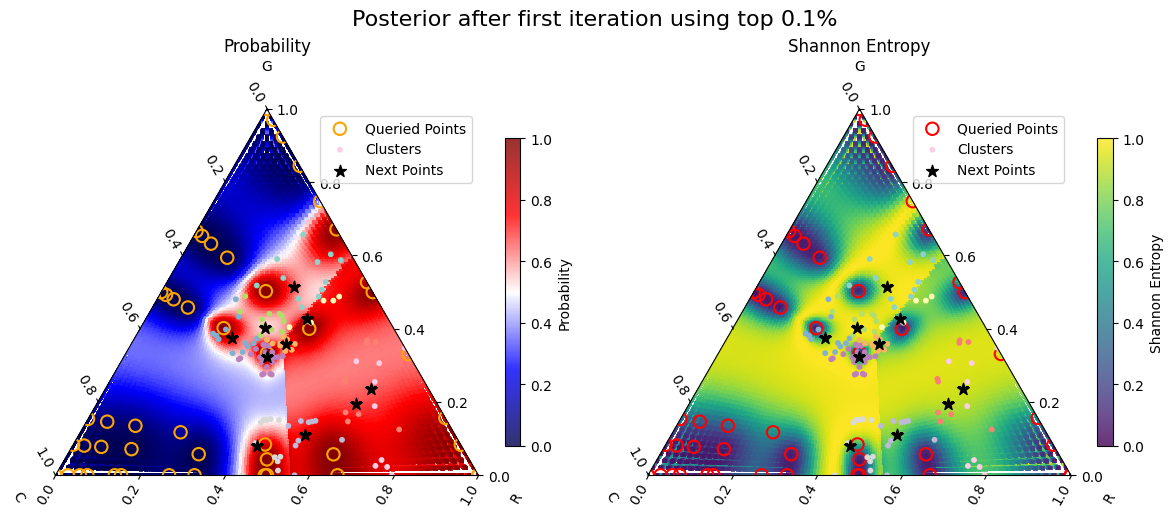

In [68]:
# ---------------------------
# Plotting the Iteration Result
# ---------------------------
# Create a figure with two subplots side-by-side.
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5), subplot_kw={'projection': 'ternary'})

# Cluster visualization
cmap = mpl.colormaps['Set3']
cluster_colors = [cmap(label) for label in cluster_labels]

# Left subplot: Predicted probability (from GP using the CDF) that density > threshold.
sc1 = ax1.scatter(df_grid["G"], df_grid["C"], df_grid["R"],
                    c=df_grid['Predicted_Probability'], cmap='seismic', s=10, marker='s', 
                    edgecolors='none', alpha=0.8, vmin=0, vmax=1)
cb1 = fig.colorbar(sc1, ax=ax1, shrink=0.8)
cb1.set_label('Probability')
ax1.scatter(df_train["G"], df_train["C"], df_train["R"],
            facecolors='none', edgecolors='orange', s=80, linewidths=1.5, label="Queried Points")
ax1.scatter(df_grid_candidates["G"], df_grid_candidates["C"], df_grid_candidates["R"],
            color=cluster_colors, s=10, label="Clusters")
ax1.scatter(df_grid_candidates_medoids["G"], df_grid_candidates_medoids["C"], df_grid_candidates_medoids["R"],
            color='k', marker='*', s=80, label="Next Points")
ax1.set_title(f"Probability")
ax1.legend(loc="upper right")
ax1.set_tlabel("G")
ax1.set_llabel("C")
ax1.set_rlabel("R")

# Right subplot: Continuous density prediction (raw GP mean prediction).
sc2 = ax2.scatter(df_grid["G"], df_grid["C"], df_grid["R"],
                    c=df_grid['H'], cmap='viridis', s=10, marker='s', 
                    edgecolors='none', alpha=0.8, vmin=0, vmax=1)
cb2 = fig.colorbar(sc2, ax=ax2, shrink=0.8)
cb2.set_label('Shannon Entropy')
ax2.scatter(df_train["G"], df_train["C"], df_train["R"],
            facecolors='none', edgecolors='red', s=80, linewidths=1.5, label="Queried Points")
ax2.scatter(df_grid_candidates["G"], df_grid_candidates["C"], df_grid_candidates["R"],
            color=cluster_colors, s=10, label="Clusters")
ax2.scatter(df_grid_candidates_medoids["G"], df_grid_candidates_medoids["C"], df_grid_candidates_medoids["R"],
            color='k', marker='*', s=80, label="Next Points")
ax2.set_title(f"Shannon Entropy")
ax2.legend(loc="upper right")
ax2.set_tlabel("G")
ax2.set_llabel("C")
ax2.set_rlabel("R")

plt.suptitle("Posterior after first iteration using top 0.1%", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])

# Save the figure as a single image for the iteration.
#filename = os.path.join(output_dir, f"iteration_{it+1}_method_{method}.png")
plt.savefig("posterior_iteration_1_top_0_1.png", dpi=150, bbox_inches='tight')
#plt.close(fig)
plt.show()

In [102]:
# Batch Size
N = 10

p = df_grid['Predicted_Probability'].values
H = - p*np.log2(p) - (1 - p)*np.log2(1 - p)
H = np.nan_to_num(H)
df_grid['H'] = H

top_percent = 0.1
number_top_candidates = int(top_percent/100*len(df_grid))
id_top_candidates_df_grid = np.argpartition(H, -number_top_candidates)[-number_top_candidates:]
df_grid_candidates = df_grid.loc[id_top_candidates_df_grid,:]
df_grid_candidates_array = df_grid_candidates.loc[:,['G','C','R']].values
kmedoids = KMedoids(n_clusters=N).fit(df_grid_candidates_array)
id_medoids_candidates = kmedoids.medoid_indices_
cluster_labels = kmedoids.labels_
cmap = mpl.colormaps['Set3']
cluster_colors = [cmap(label) for label in cluster_labels]

df_grid_candidates['cluster_color'] = cluster_colors
df_grid_candidates_medoids = df_grid_candidates.iloc[id_medoids_candidates,:]

MovieWriter ffmpeg unavailable; using Pillow instead.


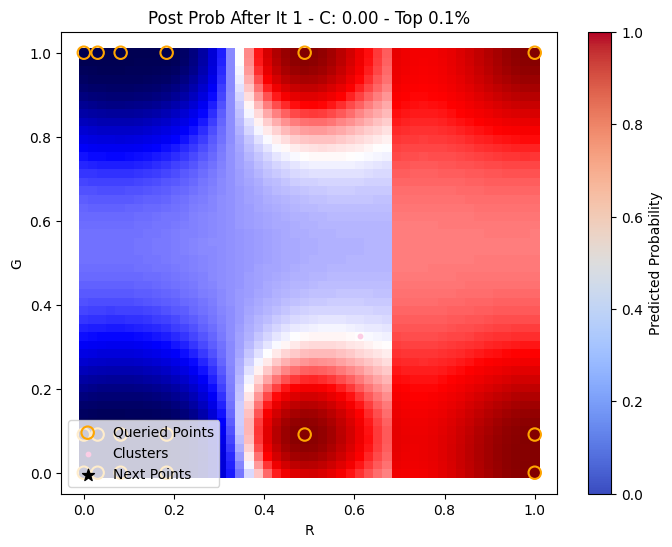

In [103]:
### ANIMATION: G vs R while C varies ###
fig, ax = plt.subplots(figsize=(8, 6))

# Extract unique `C` values for animation frames
unique_C_values = np.sort(df_grid["C"].unique())
unique_C_values_interval = (unique_C_values[1]-unique_C_values[0])/2
#print(unique_C_values)

# Create a scatter plot that will be updated in the animation
sc = ax.scatter([], [], c=[], s=[], cmap="coolwarm",vmin=0,vmax=1)

# Labels and colorbar
ax.set_xlabel("R")
ax.set_ylabel("G")
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label("Predicted Probability")

# Function to update animation frame
def update(frame):
    ax.clear()
    
    C_value = unique_C_values[frame]
    C_value_min = C_value - unique_C_values_interval
    C_value_max = C_value + unique_C_values_interval

    df_grid_subset = df_grid[df_grid["C"] == C_value]
    df_grid_candidates_subset = df_grid_candidates[df_grid_candidates["C"] == C_value]
    df_train_subset = df_train[(df_train["C"] > C_value_min) & (df_train["C"] < C_value_max)]
    df_grid_candidates_medoids_subset = df_grid_candidates_medoids[(df_grid_candidates_medoids["C"] > C_value_min) & (df_grid_candidates_medoids["C"] < C_value_max)]
    
    R = df_grid_subset["R"].values
    G = df_grid_subset["G"].values
    predictions = df_grid_subset["Predicted_Probability"].values
    #std_dev = df_grid_subset["Std_Dev"].values
    
    sc = ax.scatter(R, G, c=predictions, cmap="seismic", edgecolor="None",marker='s',s=55,vmin=0,vmax=1)
    ax.scatter(df_train_subset["R"], df_train_subset["G"],
                facecolors='none', edgecolors='orange', s=80, linewidths=1.5, label="Queried Points")
    ax.scatter(df_grid_candidates_subset["R"], df_grid_candidates_subset["G"],
                color=df_grid_candidates_subset['cluster_color'], s=10, label="Clusters")
    ax.scatter(df_grid_candidates_medoids_subset["R"], df_grid_candidates_medoids_subset["G"],
                color='k', marker='*', s=80, label="Next Points")
    ax.set_title(f"Post Prob After It 1 - C: {C_value:.2f} - Top {top_percent}%")
    ax.set_xlabel("R")
    ax.set_ylabel("G")
    ax.legend(loc='lower left')
    
    return sc,

# Create the animation
ani = animation.FuncAnimation(fig, update, frames=len(unique_C_values), interval=5, blit=False)
ani.save(f'posterior_iteration_1_top_{top_percent:_}.gif', fps=5)